<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 168 &middot; Capstone 9 &middot; Chi-Square Goodness-of-Fit</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Is Web Traffic Really Spread Evenly?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">One categorical variable against an expected distribution. The arithmetic is easy; the judgment is not, because the expected distribution is not given to you by the data. It is a claim you supply, and the test can only answer the question you actually asked.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, DARK, BL, RD, GR, MUT = "#b45309", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-website-visits-by-weekday.xlsx"
try:
    v     = pd.read_excel("../../data/" + fn, sheet_name="visits")
    prior = pd.read_excel("../../data/" + fn, sheet_name="PriorYear")
except FileNotFoundError:
    v     = pd.read_excel(BASE + fn, sheet_name="visits")
    prior = pd.read_excel(BASE + fn, sheet_name="PriorYear")
DAYS = list(v.weekday)
print(v.to_string(index=False))

  weekday  visits
   Monday     525
  Tuesday     569
Wednesday     578
 Thursday     553
   Friday     510
 Saturday     406
   Sunday     373


## Step 1 &middot; Goal and hypotheses
A company has one quarter of website traffic totaled by day of week. Somebody in marketing has asserted that traffic is **spread evenly across the week**, and wants to know whether the data support that.

There is only one variable here, day of week, so this is not a test of association. It is a comparison of one categorical variable against a **claimed distribution**.
- **H&#8320; (null):** visits are distributed **uniformly**, one seventh on each day.
- **H&#8321; (alternative):** the distribution is not uniform.
- **&#945; = 0.05.**

The word to notice is *uniformly*. That distribution is not something the data supplies; it is the claim being tested, and Step 8 shows how much the conclusion depends on it.

## Step 2 &middot; Know the data type
One **nominal** variable with seven categories, and a **count** for each. There is nothing to average and no second variable to cross against. One categorical variable compared to an expected distribution is the setting for a **chi-square goodness-of-fit test**.

In [2]:
print("total visits:", v.visits.sum())
print("categories   :", len(v))
print("\nthis is ONE variable across 7 categories -> goodness-of-fit,")
print("not TWO variables cross-tabulated -> that would be a test of independence (Capstone 8).")

total visits: 3514
categories   : 7

this is ONE variable across 7 categories -> goodness-of-fit,
not TWO variables cross-tabulated -> that would be a test of independence (Capstone 8).


**The distinction that matters.** [Capstone 8](../../capstone-commute-mode-by-region.html) had two variables and asked whether they were related. Here there is one variable and an external claim about how it should be distributed. The same chi-square machinery serves both, but the hypotheses are different in kind.

## Step 3 &middot; Describe and visualize

  weekday  visits  share
   Monday     525   14.9
  Tuesday     569   16.2
Wednesday     578   16.4
 Thursday     553   15.7
   Friday     510   14.5
 Saturday     406   11.6
   Sunday     373   10.6


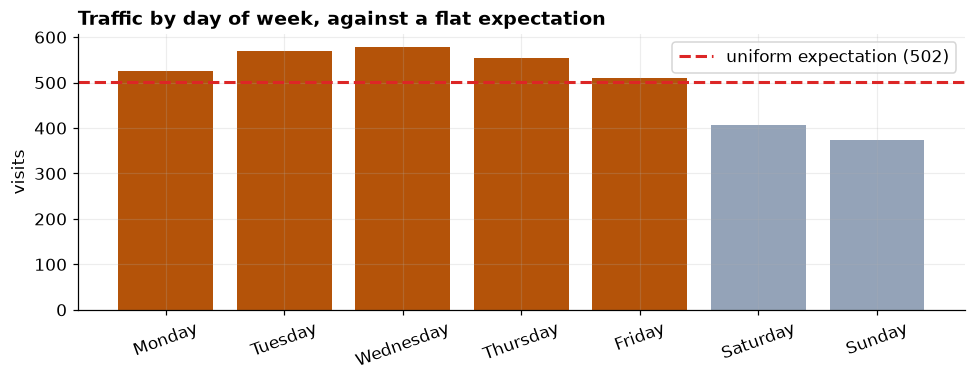

In [3]:
tot = v.visits.sum()
v2 = v.assign(share=(v.visits/tot*100).round(1))
print(v2.to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 3.6))
cols = [GOLD if d not in ("Saturday","Sunday") else MUT for d in DAYS]
ax.bar(DAYS, v.visits, color=cols)
ax.axhline(tot/7, color=RD, lw=2, ls="--", label=f"uniform expectation ({tot/7:.0f})")
ax.set_ylabel("visits"); ax.set_title("Traffic by day of week, against a flat expectation")
ax.tick_params(axis="x", rotation=20); ax.legend()
plt.tight_layout(); plt.show()

**What the picture shows.** Weekdays cluster above the flat line and both weekend days fall clearly below it, with Sunday the lowest at about 373 against an expected 502. The pattern is not noise scattered around the line; it is a systematic weekday-versus-weekend split. Whether that counts as a *finding* is the question Step 8 reopens.

## Step 4 &middot; Prepare
There is little to clean here: the data arrive as seven aggregated counts. The checks worth making are that every category is present, that counts are whole non-negative numbers, and that nothing is missing.

In [4]:
assert len(v)==7 and v.weekday.nunique()==7, "expected exactly 7 distinct weekdays"
assert v.visits.notna().all() and (v.visits>=0).all(), "counts must be present and non-negative"
print("7 categories, all present, no missing or negative counts.")
print("aggregated data: no duplicates or impossible values to remove at the row level.")

7 categories, all present, no missing or negative counts.
aggregated data: no duplicates or impossible values to remove at the row level.


**A caution that replaces cleaning.** Because the data are already aggregated, the usual cleaning steps have nothing to bite on, and that is itself a risk: any error made upstream, a bot filter that misfired, a day of tracking outage, is now invisible. With pre-aggregated counts the provenance question matters more, not less.

## Step 5 &middot; Name the design
One sample, one categorical variable, seven mutually exclusive categories, compared against a fully specified expected distribution. Degrees of freedom are k &#8722; 1 = 6, because once six category counts are known the seventh is determined by the total.

## Step 6 &middot; Check the assumption
Goodness-of-fit needs the same condition as the test of independence: every **expected** count should be about **5 or more**. With thousands of visits spread over seven days this is not close to binding.

In [5]:
exp_uniform = np.repeat(tot/7, 7)
print(f"expected count per day under uniform: {exp_uniform[0]:.1f}")
print("smallest expected count:", round(exp_uniform.min(),1))
print("assumption satisfied" if exp_uniform.min()>=5 else "too small")

expected count per day under uniform: 502.0
smallest expected count: 502.0
assumption satisfied


## Step 7 &middot; Run the test against the uniform claim

In [6]:
chi2_u, p_u = stats.chisquare(v.visits.values, exp_uniform)
w_u = np.sqrt(chi2_u/tot)
print(f"chi-square = {chi2_u:.2f}   df = {len(v)-1}   p = {p_u:.3e}")
print(f"Cohen's w  = {w_u:.3f}   ({'small' if w_u<0.3 else 'medium' if w_u<0.5 else 'large'} effect)")
resid_u = (v.visits.values - exp_uniform)/np.sqrt(exp_uniform)
print("\nstandardized residuals:")
for d, o, e, r_ in zip(DAYS, v.visits, exp_uniform, resid_u):
    print(f"  {d:10s} observed {o:5d}   expected {e:6.1f}   resid {r_:+5.2f}")

chi-square = 78.32   df = 6   p = 7.945e-15
Cohen's w  = 0.149   (small effect)

standardized residuals:
  Monday     observed   525   expected  502.0   resid +1.03
  Tuesday    observed   569   expected  502.0   resid +2.99
  Wednesday  observed   578   expected  502.0   resid +3.39
  Thursday   observed   553   expected  502.0   resid +2.28
  Friday     observed   510   expected  502.0   resid +0.36
  Saturday   observed   406   expected  502.0   resid -4.28
  Sunday     observed   373   expected  502.0   resid -5.76


**Reading the result.** The uniform claim is rejected emphatically (p is about 8 in a hundred trillion). The residuals say where: **Saturday and Sunday** are far below a flat expectation, and midweek sits above it. But look at Cohen's w of about **0.15**, which is a **small** effect. With 3,514 visits the test has enough power to detect a modest departure, so the tiny p-value reflects the sample size as much as the size of the pattern. Significance and importance are again different questions.

## Step 8 &middot; The step that matters most: was uniform the right claim?
Here is the trap. We rejected "traffic is uniform", but nobody who runs a website expects uniform traffic. Weekends are quieter for most business sites, and that is ordinary rather than newsworthy. A goodness-of-fit test does not evaluate whether data are "normal" or "fine"; it evaluates the **specific distribution you handed it**. Change the claim and you change the answer.

So we test a second, business-informed claim: that this quarter's traffic matches **last year's day-of-week shares**, which already reflect the weekend dip.

In [7]:
print("prior-year day-of-week shares:\n")
print(prior.to_string(index=False))
exp_prior = prior.prior_year_share.values*tot
chi2_p, p_p = stats.chisquare(v.visits.values, exp_prior)
w_p = np.sqrt(chi2_p/tot)
print(f"\nchi-square = {chi2_p:.2f}   df = {len(v)-1}   p = {p_p:.4f}")
print(f"Cohen's w  = {w_p:.3f}")
print("\nverdict:", "REJECT: traffic differs from last year" if p_p<0.05
      else "DO NOT REJECT: this quarter looks just like last year")

prior-year day-of-week shares:

  weekday  prior_year_share
   Monday             0.150
  Tuesday             0.160
Wednesday             0.163
 Thursday             0.157
   Friday             0.145
 Saturday             0.116
   Sunday             0.109

chi-square = 0.41   df = 6   p = 0.9988
Cohen's w  = 0.011

verdict: DO NOT REJECT: this quarter looks just like last year


**The same data, the opposite conclusion.** Against a uniform claim, p is effectively zero and the traffic looks dramatically irregular. Against last year's pattern, p is **0.9988** and the traffic looks utterly ordinary. Nothing about the data changed between those two tests; only the expected distribution changed. That is the whole lesson of this capstone: **in a goodness-of-fit test, the expected distribution is the hypothesis**, and a rejection tells you the data disagree with *that model*, not that something is wrong.

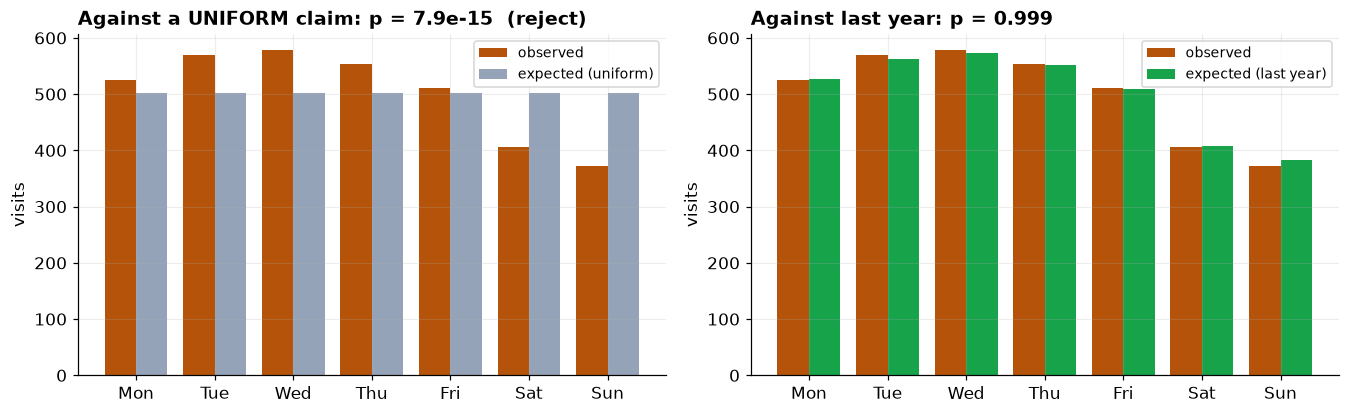

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12.4, 3.9))
x = np.arange(7)
ax[0].bar(x-0.2, v.visits, 0.4, color=GOLD, label="observed")
ax[0].bar(x+0.2, exp_uniform, 0.4, color=MUT, label="expected (uniform)")
ax[0].set_xticks(x); ax[0].set_xticklabels([d[:3] for d in DAYS])
ax[0].set_ylabel("visits"); ax[0].legend(fontsize=9)
ax[0].set_title(f"Against a UNIFORM claim: p = {p_u:.1e}  (reject)")
ax[1].bar(x-0.2, v.visits, 0.4, color=GOLD, label="observed")
ax[1].bar(x+0.2, exp_prior, 0.4, color=GR, label="expected (last year)")
ax[1].set_xticks(x); ax[1].set_xticklabels([d[:3] for d in DAYS])
ax[1].set_ylabel("visits"); ax[1].legend(fontsize=9)
ax[1].set_title(f"Against last year: p = {p_p:.3f}")
plt.tight_layout(); plt.show()

**Two panels, one dataset.** On the left the observed bars diverge visibly from a flat expectation. On the right the same observed bars sit almost exactly on last year's expectation. A reader shown only the left panel would conclude something notable had happened; a reader shown only the right panel would conclude nothing had. Both would be reading a correct test.

## Step 9 &middot; Estimate, do not just test
Two chi-square tests gave two verdicts. Neither said how far any particular day sits from its expectation, which is the only form in which this result can reach a planning meeting.

In [9]:
from statsmodels.stats.proportion import proportion_confint

print(f"{'day':10s} {'visits':>7s} {'share':>7s}  {'95% CI (Wilson)':>18s}  {'vs an even split':>14s}")
print("-"*66)
for d, obs in zip(DAYS, v.visits.values):
    l_, h_ = proportion_confint(int(obs), int(tot), method="wilson")
    flag = "above" if l_ > 1/7 else ("below" if h_ < 1/7 else "contains 1/7")
    print(f"{d:10s} {obs:7d} {obs/tot*100:6.2f}%  [{l_*100:5.2f}%, {h_*100:5.2f}%]  {flag:>13s}")
print(f"\nan even split would put every day at {100/7:.2f}%")

# An interval for the effect size of the uniform test, by resampling visits.
rng_w = np.random.default_rng(9)
probs = v.visits.values/tot
reps = []
for _ in range(4000):
    samp = rng_w.multinomial(int(tot), probs)
    reps.append(np.sqrt(stats.chisquare(samp, np.repeat(tot/7, 7))[0]/tot))
w_lo, w_hi = np.percentile(reps, [2.5, 97.5])
print(f"\nCohen's w vs uniform   {w_u:.3f}   95% CI [{w_lo:.3f}, {w_hi:.3f}]")
print("small by convention (0.1), and the interval confirms it is not a large effect")

day         visits   share     95% CI (Wilson)  vs an even split
------------------------------------------------------------------
Monday         525  14.94%  [13.80%, 16.16%]   contains 1/7
Tuesday        569  16.19%  [15.01%, 17.45%]          above
Wednesday      578  16.45%  [15.26%, 17.71%]          above
Thursday       553  15.74%  [14.57%, 16.98%]          above
Friday         510  14.51%  [13.39%, 15.72%]   contains 1/7
Saturday       406  11.55%  [10.54%, 12.65%]          below
Sunday         373  10.61%  [ 9.64%, 11.68%]          below

an even split would put every day at 14.29%



Cohen's w vs uniform   0.149   95% CI [0.124, 0.186]
small by convention (0.1), and the interval confirms it is not a large effect


**Every day gets a margin, and the picture sharpens.** Tuesday, Wednesday and Thursday sit entirely above the 14.29 percent an even split would give, and Saturday and Sunday sit entirely below it. **Monday and Friday are the interesting cases**: both of their intervals contain 14.29 percent, so the two ends of the working week are the days this quarter cannot distinguish from an even share. The weekday-versus-weekend story is really a midweek-versus-weekend story, with Monday and Friday sitting on the fence. The omnibus test could never have told us that, because it collapses seven deviations into a single number.

Cohen's w of 0.149 also carries an interval, and the whole of it stays in "small" territory. This matters for how the result is sold. Traffic is not evenly spread, and the departure from even is real, but it is not dramatic. A p-value of 8 x 10<sup>-15</sup> is a statement about how confident we are that the pattern is not chance, and it is routinely misread as a statement about how big the pattern is. **The interval on the effect size is what stops that misreading.**

## Step 10 &middot; Interpret in plain language
Traffic is **not** evenly spread across the week: weekdays run about a fifth above the weekend, with Sunday the quietest day. But that is a description of normal business traffic rather than a discovery. Measured against last year's day-of-week pattern, this quarter is indistinguishable from expectation, so there is no anomaly to investigate and no change to explain. The honest one-line summary is "traffic is uneven across the week, in exactly the way it always has been".

## Step 11 &middot; Ethics, bias, and limits
- **The expected distribution is a claim, not a fact.** Choosing a null that nobody believes and then rejecting it produces a technically valid, practically empty finding. Worse, it can be used to manufacture significance, which is why the expected model should be stated and justified *before* the test.
- **Large samples make small departures significant.** Cohen's w of 0.15 is small; the p-value of 8 &#215; 10&#8315;&#185;&#8309; comes largely from having 3,514 visits. Report the effect size, and decide in advance what size of departure would actually matter.
- **Aggregated data hides its own problems.** Seven totals cannot reveal a bot surge on one afternoon, a tracking outage, or a redirect that misattributed a day. Pre-aggregation removes the ability to audit.
- **A quarter is a season.** Day-of-week patterns shift with holidays, campaigns, and school terms. This quarter's shape may not transfer to the next, and last year's shares are themselves an estimate carrying their own uncertainty, which this test treats as exact.

---
**From analysis to report.** The notebook carries the evidence: the counts, the assumption check, both tests, the residuals, and the side-by-side comparison of the two expected models. The written reports turn it into something a marketing lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.